# Atividade 1 de Matemática Computacional: Transformações e Produto Escalar

## Funções Auxiliares e Matrizes de Transformação

Reutilizando e adaptando as funções auxiliares fornecidas no exemplo para garantir a correta aplicação das transformações e visualização do determinante.

A matriz de rotação horária de 90° é:
$$
M_{rot} = \begin{bmatrix}
\cos(-90^\circ) & -\sin(-90^\circ) \\
\sin(-90^\circ) & \cos(-90^\circ)
\end{bmatrix} =
\begin{bmatrix}
0 & 1 \\
-1 & 0
\end{bmatrix}
$$

A matriz de Shear (Cisalhamento) em X com $k=2$ é:
$$
M_{shear} = \begin{bmatrix}
1 & k \\
0 & 1
\end{bmatrix} =
\begin{bmatrix}
1 & 2 \\
0 & 1
\end{bmatrix}
$$

## Configuração para plotagem dos gráficos

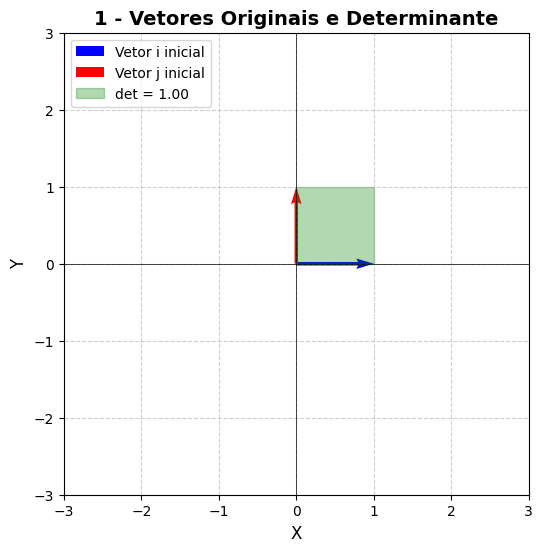

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Funções Auxiliares ---

def draw_graph(name: str, vectors, show_area = False, xlim=(-6, 7), ylim=(-6, 7)):
    plt.figure(figsize=(6, 6))

    for vec in vectors:
        plt.quiver(0, 0, vec["x"], vec["y"], angles='xy', scale_units='xy', scale=1, color=vec["color"], label=vec["name"])

    if show_area and len(vectors) == 2:
        v1 = np.array([vectors[0]["x"], vectors[0]["y"]])
        v2 = np.array([vectors[1]["x"], vectors[1]["y"]])
        
        # Calculate the vertices of the parallelogram
        matrix_v = np.column_stack((v1, v2))
        det_val = np.linalg.det(matrix_v)
        
        # Calculate the vertices of the parallelogram
        corners = np.array([[0,0], v1, v1+v2, v2, [0,0]])
        
        # Fill the parallelogram
        plt.fill(corners[:,0], corners[:,1], color='green', alpha=0.3,
                 label=f"det = {abs(det_val):.2f}")


    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    plt.xticks(range(xlim[0], xlim[1] + 1))
    plt.yticks(range(ylim[0], ylim[1] + 1))

    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.legend(loc='upper left')
    plt.xlabel("X", fontsize=12)
    plt.ylabel("Y", fontsize=12)
    plt.title(name, fontsize=14, fontweight='bold')
    
    plt.show()

def transform_vector(vector, matrix):
    # Multiplicação padrão de matriz x vetor
    return matrix @ vector

def create_shear_matrix(k):
    # Shear na direção X: [1 k]
    #                     [0 1]
    return np.array([[1, k], [0, 1]])

def create_rotation_matrix_clockwise(degrees):
    # Rotação em sentido horário: R(-theta)
    theta = np.deg2rad(-degrees) 
    return np.array([[np.cos(theta), -np.sin(theta)], 
                     [np.sin(theta), np.cos(theta)]])

def determinant_2d(v1, v2):
    # Determinante da matriz formada por v1 e v2 como colunas    
    matrix = np.column_stack((v1, v2))
    return np.linalg.det(matrix)

def compose_matrices(m2, m1):
    # Composição de transformações: M1 aplicado primeiro, então M2.
    # A matriz resultante para a composição é M2 * M1.
    return m2 @ m1

# --- Definição das Matrizes e Vetores ---
rotation_matrix = create_rotation_matrix_clockwise(90)
k = 2
shear_matrix = create_shear_matrix(k)

initial_i = np.array([1, 0])
initial_j = np.array([0, 1])

# Visualização inicial
draw_graph("1 - Vetores Originais e Determinante",
    [
        {"name": "Vetor i inicial", "x": initial_i[0], "y": initial_i[1], "color": "blue"},
        {"name": "Vetor j inicial", "x": initial_j[0], "y": initial_j[1], "color": "red"},
    ],
    True,
    xlim=(-3, 3), ylim=(-3, 3)
)

### 1 e 2: Rotação Horária de 90° seguida de Shear ($k=2$) e Análise do Determinante

#### 1.1 Rotação Horária de $90^\circ$

Aplicamos a matriz de rotação $M_{rot}$ aos vetores base $\vec{i} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ e $\vec{j} = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$:
$$
\vec{i'} = M_{rot} \vec{i} = \begin{bmatrix} 0 \\ -1 \end{bmatrix} \quad \vec{j'} = M_{rot} \vec{j} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}
$$
O determinante da matriz de rotação é $\det(M_{rot}) = 1$. A área é preservada.

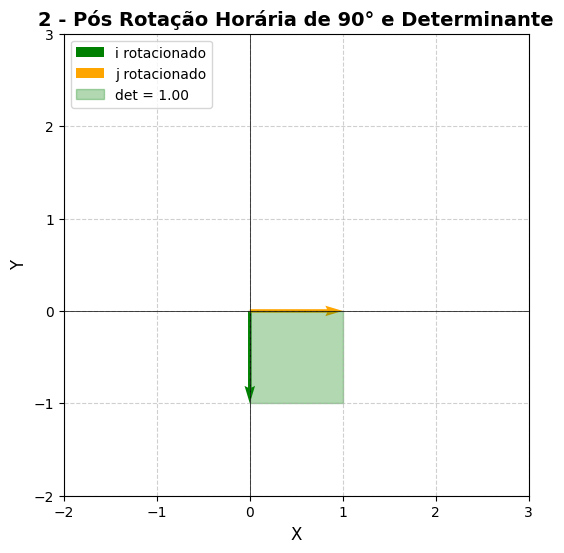

Vetor i' (Pós Rotação): [ 6.123234e-17 -1.000000e+00]
Vetor j' (Pós Rotação): [1.000000e+00 6.123234e-17]
Determinante Pós Rotação: 1.00


In [ ]:
# --- Rotação (M_rot) ---
rotated_i = transform_vector(initial_i, rotation_matrix)
rotated_j = transform_vector(initial_j, rotation_matrix)

draw_graph("2 - Pós Rotação Horária de 90° e Determinante",
    [
        {"name": "i rotacionado", "x": rotated_i[0], "y": rotated_i[1], "color": "green"},
        {"name": "j rotacionado", "x": rotated_j[0], "y": rotated_j[1], "color": "orange"},
    ],
    True,
    xlim=(-3, 3), ylim=(-3, 3)
)

print(f"Vetor i' (Pós Rotação): {rotated_i}")
print(f"Vetor j' (Pós Rotação): {rotated_j}")
print(f"Determinante Pós Rotação: {determinant_2d(rotated_i, rotated_j):.2f}")

#### 1.2 Shear (Cisalhamento) em X com $k=2$

Aplicamos a matriz de shear $M_{shear}$ aos vetores rotacionados ($\vec{i'}$ e $\vec{j'}$):
$$
\vec{i''} = M_{shear} \vec{i'} = \begin{bmatrix} -2 \\ -1 \end{bmatrix} \quad \vec{j''} = M_{shear} \vec{j'} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}
$$

O determinante final é o produto dos determinantes: $\det(M_{shear} M_{rot}) = \det(M_{shear}) \cdot \det(M_{rot}) = 1 \cdot 1 = 1$.

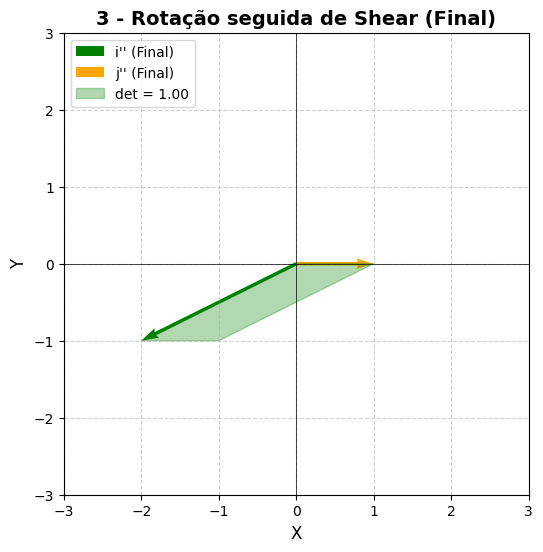

Vetor i'' (Final): [-2. -1.]
Vetor j'' (Final): [1.000000e+00 6.123234e-17]
Determinante Final: 1.00


In [5]:
# --- Shear (M_shear) ---
sheared_i = transform_vector(rotated_i, shear_matrix)
sheared_j = transform_vector(rotated_j, shear_matrix)

draw_graph("3 - Rotação seguida de Shear (Final)",
    [
        {"name": "i'' (Final)", "x": sheared_i[0], "y": sheared_i[1], "color": "green"},
        {"name": "j'' (Final)", "x": sheared_j[0], "y": sheared_j[1], "color": "orange"},
    ],
    True,
    xlim=(-3, 3), ylim=(-3, 3)
)

print(f"Vetor i'' (Final): {sheared_i}")
print(f"Vetor j'' (Final): {sheared_j}")
print(f"Determinante Final: {determinant_2d(sheared_i, sheared_j):.2f}")

### 2. Análise do Determinante

O determinante final é 1,00.

* Explicação: O determinante mede a variação de área causada pela transformação linear. Como o determinante final é $\det(M_{final}) = 1$, a área do paralelogramo formado pelos vetores não foi alterada pela composição das transformações (rotação e cisalhamento). A transformação preserva a área.

### 3: Multiplicação de Matrizes por Composição

#### 3.1 Composição: Rotação seguida de Shear ($M_{shear} M_{rot}$)

A rotação é aplicada primeiro ($M_{rot}$), seguida pelo shear ($M_{shear}$).
$$
M_{final} = M_{shear} M_{rot} = \begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} = \begin{bmatrix} -2 & 1 \\ -1 & 0 \end{bmatrix}
$$

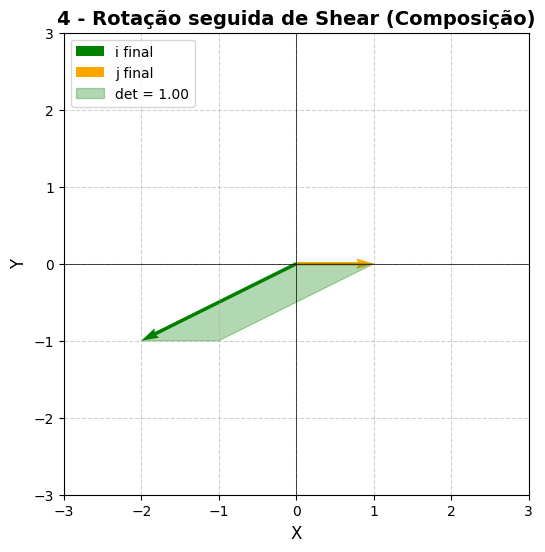

Matriz M_final (Shear * Rotação):
[[-2.000000e+00  1.000000e+00]
 [-1.000000e+00  6.123234e-17]]
Determinante de M_final: 1.00


In [ ]:
# --- Composição: Shear * Rotação ---
composite_matrix = compose_matrices(shear_matrix, rotation_matrix)
final_i_RS = transform_vector(initial_i, composite_matrix)
final_j_RS = transform_vector(initial_j, composite_matrix)

draw_graph("4 - Rotação seguida de Shear (Composição)",
    [
        {"name": "i final", "x": final_i_RS[0], "y": final_i_RS[1], "color": "green"},
        {"name": "j final", "x": final_j_RS[0], "y": final_j_RS[1], "color": "orange"},
    ],
    True,
    xlim=(-3, 3), ylim=(-3, 3)
)

print("Matriz M_final (Shear * Rotação):")
print(composite_matrix)
print(f"Determinante de M_final: {np.linalg.det(composite_matrix):.2f}")

# --- Invertando a ordem das transformações

#### 3.2 Composição: Shear seguido de Rotação ($M_{rot} M_{shear}$)

O shear é aplicado primeiro ($M_{shear}$), seguido pela rotação ($M_{rot}$).
$$
M_{final} = M_{rot} M_{shear} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} \begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -1 & -2 \end{bmatrix}
$$

Conclusão da Composição:
As matrizes resultantes $M_{shear} M_{rot}$ e $M_{rot} M_{shear}$ são diferentes. Isso demonstra que a ordem em que as transformações lineares são aplicadas é crucial (a multiplicação de matrizes não é comutativa).

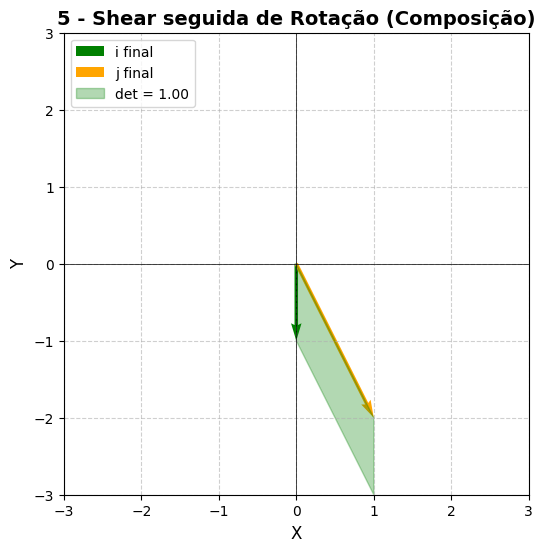

Matriz M_final (Rotação * Shear):
[[ 6.123234e-17  1.000000e+00]
 [-1.000000e+00 -2.000000e+00]]
Determinante de M_final: 1.00


In [7]:
# --- Composição: Rotação * Shear ---
matrix_S_then_R = compose_matrices(rotation_matrix, shear_matrix)
final_i_SR = transform_vector(initial_i, matrix_S_then_R)
final_j_SR = transform_vector(initial_j, matrix_S_then_R)

draw_graph("5 - Shear seguida de Rotação (Composição)",
    [
        {"name": "i final", "x": final_i_SR[0], "y": final_i_SR[1], "color": "green"},
        {"name": "j final", "x": final_j_SR[0], "y": final_j_SR[1], "color": "orange"},
    ],
    True,
    xlim=(-3, 3), ylim=(-3, 3)
)

print("Matriz M_final (Rotação * Shear):")
print(matrix_S_then_R)
print(f"Determinante de M_final: {np.linalg.det(matrix_S_then_R):.2f}")

### 4: Vetor $\vec{x}$ e $\vec{y}$ (Rotação de 90°)

Tomamos o vetor $\vec{x} = \begin{bmatrix} 2 \\ 1 \end{bmatrix}$ e o rotacionamos em $90^\circ$ horário para obter $\vec{y} = \begin{bmatrix} 1 \\ -2 \end{bmatrix}$.

O produto escalar $\vec{x} \cdot \vec{y}$ é:
$$
\vec{x} \cdot \vec{y} = (2)(1) + (1)(-2) = 2 - 2 = 0
$$

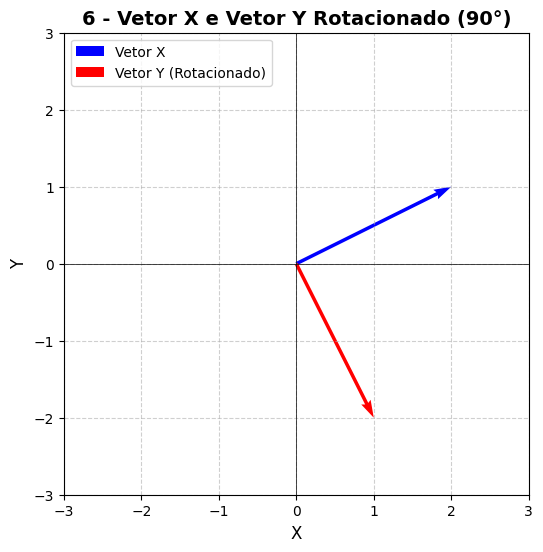

Vetor X: [2 1]
Vetor Y (Pós Rotação): [ 1. -2.]
Produto escalar entre X e Y: 4.440892098500626e-16


In [8]:
# --- Definição e Transformação dos Vetores ---
vec_x = np.array([2, 1])
vec_y = transform_vector(vec_x, rotation_matrix)

# --- Visualização ---
draw_graph("6 - Vetor X e Vetor Y Rotacionado (90°)",
    [
        {"name": "Vetor X", "x": vec_x[0], "y": vec_x[1], "color": "blue"},
        {"name": "Vetor Y (Rotacionado)", "x": vec_y[0], "y": vec_y[1], "color": "red"},
    ],
    xlim=(-3, 3), ylim=(-3, 3)
)

# --- Produto Escalar ---
dot_product_90deg = np.dot(vec_x, vec_y)
print(f"Vetor X: {vec_x}")
print(f"Vetor Y (Pós Rotação): {vec_y}")
print(f"Produto escalar entre X e Y: {dot_product_90deg}")

Resultado:
O produto escalar entre $\vec{x}$ e $\vec{y}$ é zero. Geometricamente, isso confirma que os dois vetores são ortogonais (perpendiculares), uma vez que $\vec{y}$ foi obtido por uma rotação exata de $90^\circ$ em $\vec{x}$.

### 5: Análise do Produto Escalar ($\vec{v_1} \cdot \vec{v_2}$)

Análise do código:

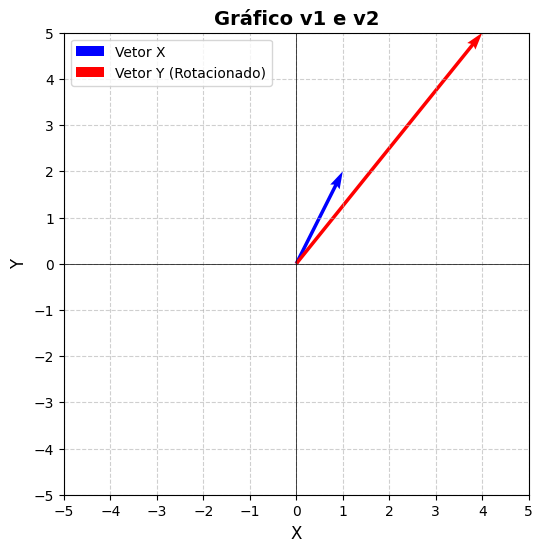

14


In [12]:
v1 = np.array([1, 2])
v2 = np.array([4, 5])

draw_graph("Gráfico v1 e v2",
    [
        {"name": "Vetor X", "x": v1[0], "y": v1[1], "color": "blue"},
        {"name": "Vetor Y (Rotacionado)", "x": v2[0], "y": v2[1], "color": "red"},
    ],
    xlim=(-5, 5), ylim=(-5, 5)
)

dot = np.dot(v1, v2)
print(dot)

Conclusão:
O produto escalar é diferente de zero, logo, os vetores $\vec{v_1}$ e $\vec{v_2}$ não são perpendiculares. O resultado ser positivo ($14 > 0$) indica que o ângulo entre eles é agudo, ou seja, os vetores apontam parcialmente na mesma direção.